In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "14"
os.environ["MKL_NUM_THREADS"] = "14"

import numpy as np, pandas as pd, scanpy as sc, yaml, glob
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from sklearn.metrics import f1_score, cohen_kappa_score, classification_report

ROOT = Path("..").resolve()
FIG = ROOT / "results/figures"
FIG.mkdir(parents=True, exist_ok=True)

adata = sc.read_h5ad(ROOT / "data/processed/pbmc3k.h5ad")

ct_input = adata.copy()
sc.pp.normalize_total(ct_input, target_sum=1e4)
sc.pp.log1p(ct_input)

print(adata)

AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'cell_type'
    var: 'gene_ids', 'n_cells'
    obsm: 'X_umap_ref'
    layers: 'counts'


In [2]:
# Ontology Map

import yaml

with open(ROOT / "configs/ontology_map.yaml") as f:
    omap = yaml.safe_load(f)

print("sections:", list(omap.keys()))
for k in omap:
    print(f"  {k}: {len(omap[k])} entries")

sections: ['louvain', 'celltypist_high', 'celltypist_low', 'singler_fine']
  louvain: 8 entries
  celltypist_high: 14 entries
  celltypist_low: 41 entries
  singler_fine: 27 entries


In [3]:
# Load predictions (file contract format)
ct_high = pd.read_csv(ROOT / "results/predictions_celltypist_high_pbmc3k.csv").set_index("barcode").loc[adata.obs_names]
ct_low  = pd.read_csv(ROOT / "results/predictions_celltypist_low_pbmc3k.csv").set_index("barcode").loc[adata.obs_names]
singler = pd.read_csv(ROOT / "results/predictions_singler_hpca_fine_pbmc3k.csv").set_index("barcode").loc[adata.obs_names]

actinn_files = sorted(glob.glob(str(ROOT / "results/predictions_actinn_seed*_pbmc3k.csv")))
scanvi_files = sorted(glob.glob(str(ROOT / "results/predictions_scanvi_seed*_pbmc3k.csv")))

print("celltypist high:", ct_high.shape, "| low:", ct_low.shape)
print("singler:", singler.shape)
print("actinn files:", len(actinn_files), "| scanvi files:", len(scanvi_files))

celltypist high: (2638, 2) | low: (2638, 2)
singler: (2638, 2)
actinn files: 5 | scanvi files: 5


In [4]:
# Then check for unmapped labels

for key, df in [("celltypist_high", ct_high), ("celltypist_low", ct_low), ("singler_fine", singler)]:
    seen = set(df["label"].unique())
    missing = seen - set(omap[key])
    print(key, "| unmapped:", missing if missing else "none")

seen = set(adata.obs["cell_type"].unique())
print("louvain | unmapped:", seen - set(omap["louvain"]) or "none")

celltypist_high | unmapped: none
celltypist_low | unmapped: none
singler_fine | unmapped: none
louvain | unmapped: none


In [5]:
with open(ROOT / "configs/ontology_map.yaml") as f:
    omap = yaml.safe_load(f)

print("celltypist_low entries:", len(omap["celltypist_low"]))

for key, df in [("celltypist_high", ct_high), ("celltypist_low", ct_low), ("singler_fine", singler)]:
    seen = set(df["label"].unique())
    missing = seen - set(omap[key])
    print(key, "| unmapped:", missing if missing else "none")

celltypist_low entries: 41
celltypist_high | unmapped: none
celltypist_low | unmapped: none
singler_fine | unmapped: none


In [6]:
# First real comparison
truth = adata.obs["cell_type"].map(omap["louvain"]).values

for name, df in [("celltypist_high", ct_high), ("celltypist_low", ct_low)]:
    p = df["label"].map(omap[name]).values
    assigned = p != "unassigned"

    print(f"=== {name} ===")
    print(f"unassigned: {(~assigned).sum()} / {len(p)}  ({100*(~assigned).mean():.1f}%)")
    print(f"accuracy (assigned only): {(p[assigned] == truth[assigned]).mean():.3f}")
    print(f"macro-F1 (assigned only): {f1_score(truth[assigned], p[assigned], average='macro'):.3f}")
    print(f"Cohen's kappa:            {cohen_kappa_score(truth[assigned], p[assigned]):.3f}")
    print()

=== celltypist_high ===
unassigned: 2060 / 2638  (78.1%)
accuracy (assigned only): 0.917
macro-F1 (assigned only): 0.540
Cohen's kappa:            0.851

=== celltypist_low ===
unassigned: 42 / 2638  (1.6%)
accuracy (assigned only): 0.826
macro-F1 (assigned only): 0.814
Cohen's kappa:            0.774



In [7]:
p_low = ct_low["label"].map(omap["celltypist_low"]).values
m = p_low != "unassigned"

print(pd.crosstab(pd.Series(truth[m], name="louvain"),
                  pd.Series(p_low[m], name="celltypist")))
print()
print(classification_report(truth[m], p_low[m], zero_division=0))

celltypist       B  CD4_T  CD8_T  DC  Megakaryocyte  Mono_CD14  Mono_FCGR3A  \
louvain                                                                       
CD4_T            9    889    229   3              1          1            3   
Mono_CD14        1      0      1   2              0        386           74   
B              339      0      1   1              0          0            1   
CD8_T            3     46    195   0              0          0            0   
NK               0      1      2   0              0          0            0   
Mono_FCGR3A      0      0      0   0              0          0          150   
DC               0      1      0  28              0          4            0   
Megakaryocyte    1      0      1   0             11          1            1   

celltypist      NK  
louvain             
CD4_T            2  
Mono_CD14        0  
B                0  
CD8_T           60  
NK             147  
Mono_FCGR3A      0  
DC               1  
Megakaryocyte    0  

In [8]:
# Save metrics
summary = []
for name, df in [("celltypist_high", ct_high), ("celltypist_low", ct_low)]:
    p = df["label"].map(omap[name]).values
    a = p != "unassigned"
    summary.append({
        "method": name,
        "n_total": len(p),
        "n_assigned": int(a.sum()),
        "pct_unassigned": round(100*(~a).mean(), 2),
        "accuracy": round((p[a] == truth[a]).mean(), 4),
        "macro_f1": round(f1_score(truth[a], p[a], average="macro"), 4),
        "kappa": round(cohen_kappa_score(truth[a], p[a]), 4),
    })

pd.DataFrame(summary).to_csv(ROOT / "results/metrics_celltypist_pbmc3k.csv", index=False)
pd.crosstab(pd.Series(truth[m], name="louvain"),
            pd.Series(p_low[m], name="celltypist")).to_csv(
    ROOT / "results/confusion_celltypist_low_pbmc3k.csv")
print("saved")

saved


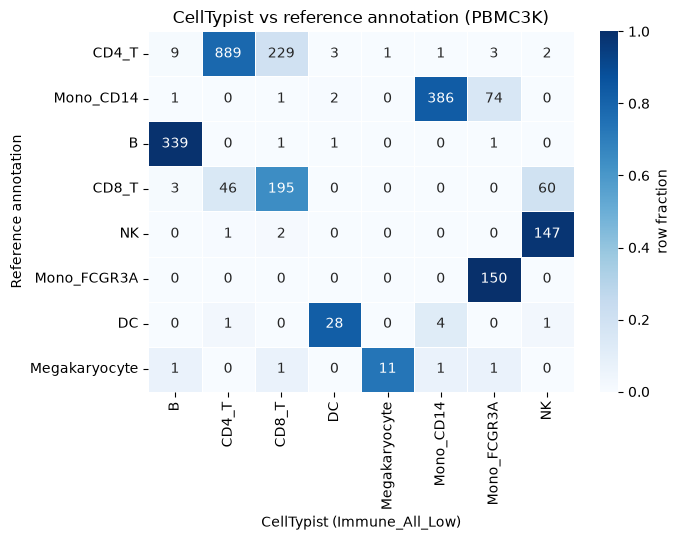

In [9]:
# Plot 1: Confusion matrix heatmap

# The table you have is informative but hard to scan. Row-normalize it so each row shows "of the cells the tutorial called X, what fraction did CellTypist call Y":

import matplotlib.pyplot as plt
import seaborn as sns

FIG = ROOT / "results/figures"
FIG.mkdir(parents=True, exist_ok=True)

cm = pd.crosstab(pd.Series(truth[m], name="Reference annotation"),
                 pd.Series(p_low[m], name="CellTypist (Immune_All_Low)"))
cm_norm = cm.div(cm.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(cm_norm, annot=cm.values, fmt="d", cmap="Blues",
            cbar_kws={"label": "row fraction"}, linewidths=0.5, ax=ax)
ax.set_title("CellTypist vs reference annotation (PBMC3K)")
plt.tight_layout()
plt.savefig(FIG / "confusion_celltypist_low.png", dpi=150)
plt.show()


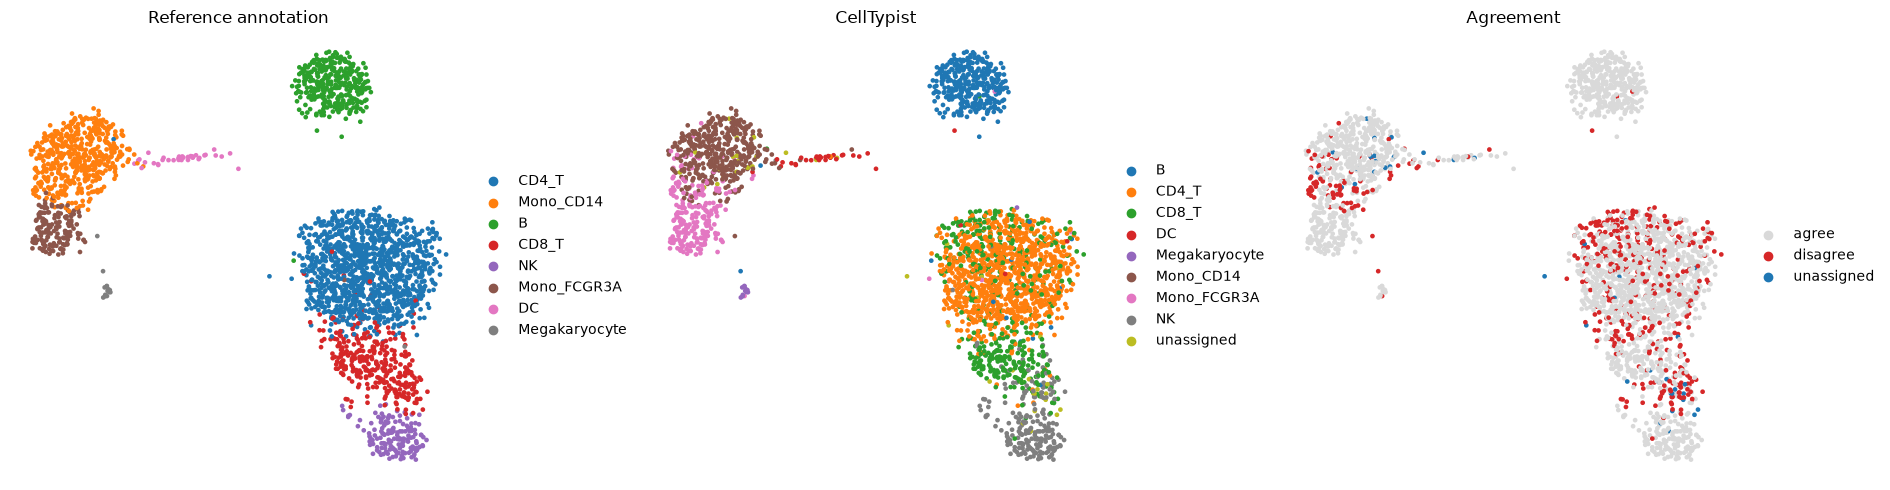

In [10]:
# Plot 2: UMAP with disagreements highlighted

adata.obs["celltypist_coarse"] = p_low
adata.obs["truth_coarse"] = truth
adata.obs["agree"] = np.where(
    p_low == "unassigned", "unassigned",
    np.where(p_low == truth, "agree", "disagree"))

adata.obsm["X_umap"] = adata.obsm["X_umap_ref"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
sc.pl.umap(adata, color="truth_coarse", ax=axes[0], show=False,
           title="Reference annotation", frameon=False)
sc.pl.umap(adata, color="celltypist_coarse", ax=axes[1], show=False,
           title="CellTypist", frameon=False)
sc.pl.umap(adata, color="agree", ax=axes[2], show=False,
           title="Agreement", frameon=False,
           palette={"agree": "#d9d9d9", "disagree": "#d62728", "unassigned": "#1f77b4"})
plt.tight_layout()
plt.savefig(FIG / "umap_celltypist_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
# Test it quantitatively
conf = ct_low["confidence"].values
adata.obs["confidence"] = conf

d = adata.obs[adata.obs["agree"] != "unassigned"]
print(d.groupby("agree", observed=True)["confidence"].describe()[["count","mean","50%"]])
print()
t = d[d["truth_coarse"].isin(["CD4_T","CD8_T"])]
print("T cells only:")
print(t.groupby("agree", observed=True)["confidence"].agg(["count","mean"]))

           count      mean       50%
agree                               
agree     2145.0  0.833333  0.944091
disagree   451.0  0.693671  0.794979

T cells only:
          count      mean
agree                    
agree      1084  0.744378
disagree    357  0.671998


In [12]:
# Check whether CD8A is actually detected in the disputed cells
cd8a = np.asarray(ct_input[:, "CD8A"].X.todense()).ravel()
adata.obs["CD8A_expr"] = cd8a

t2 = adata.obs[adata.obs["truth_coarse"].isin(["CD4_T", "CD8_T"])]
out = t2.groupby(["truth_coarse", "agree"], observed=True)["CD8A_expr"].agg(
    count="count",
    mean="mean",
    dropout=lambda x: (x == 0).mean(),
).round(3)
print(out)

                         count   mean  dropout
truth_coarse agree                            
CD4_T        agree         889  0.036    0.979
             disagree      248  0.797    0.597
             unassigned      7  0.000    1.000
CD8_T        agree         195  1.254    0.410
             disagree      109  0.564    0.725
             unassigned     12  1.696    0.250


markers found: ['CD8A', 'CD8B', 'CD4', 'IL7R', 'CCR7']


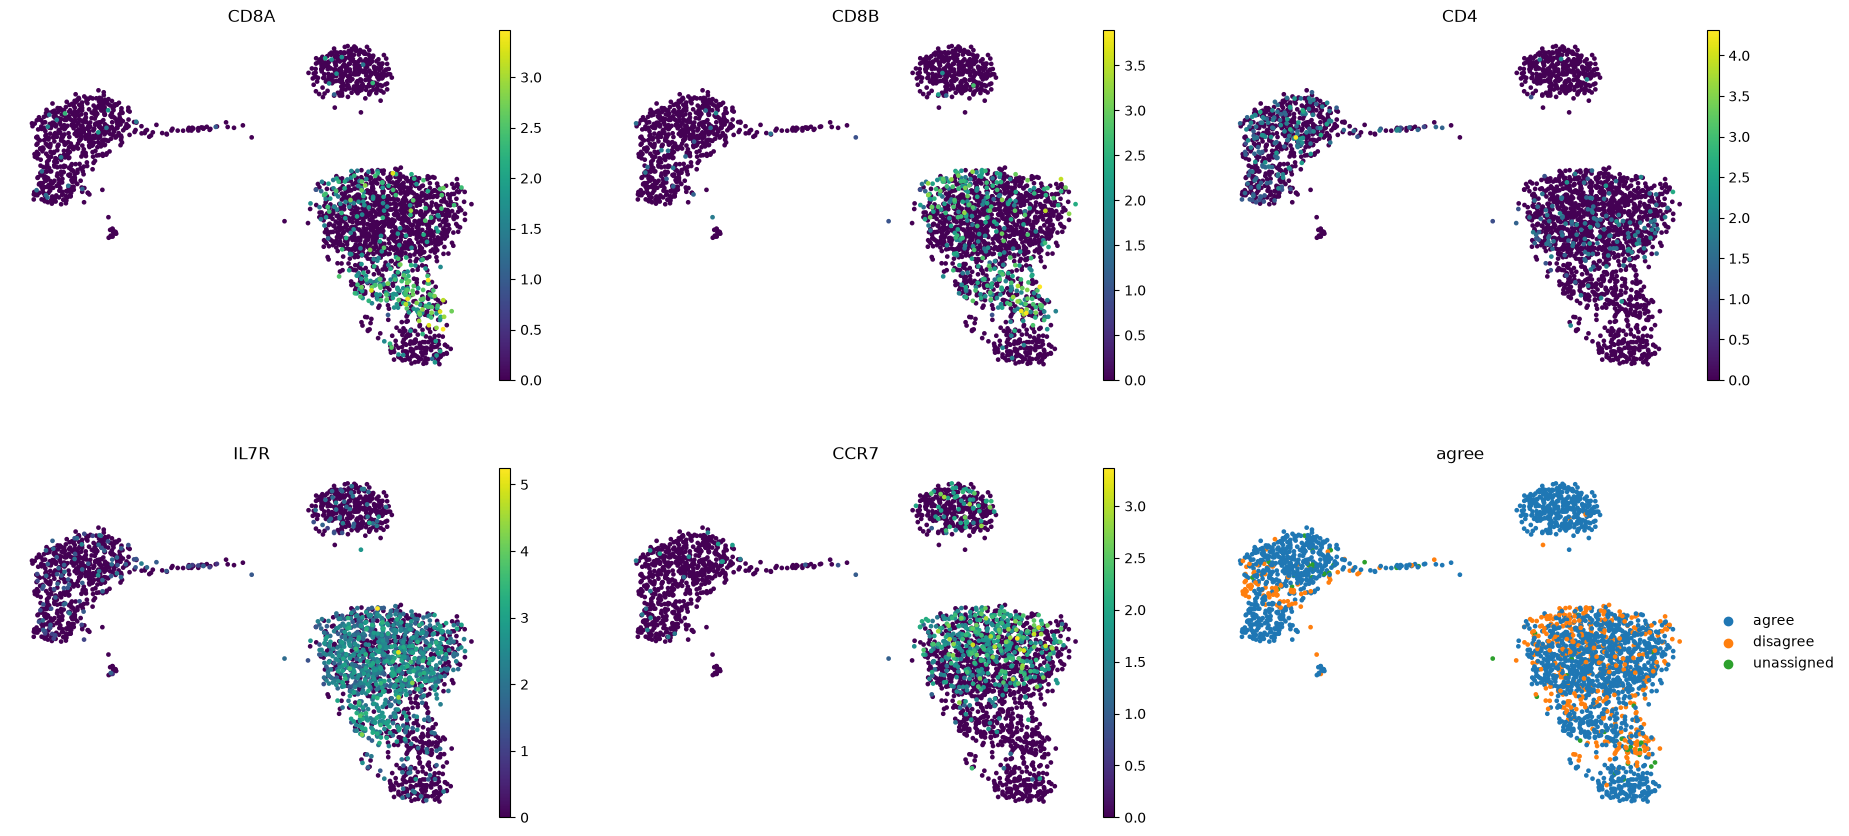

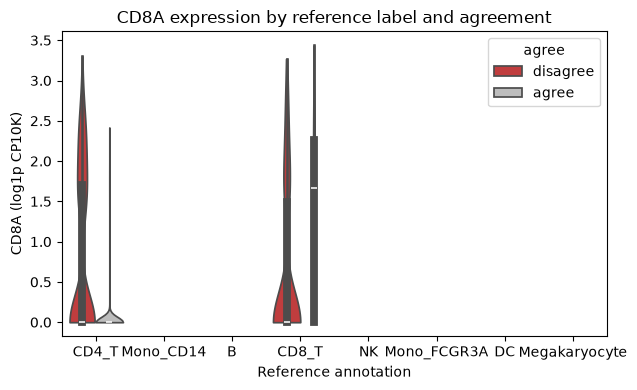

                        CD8A   CD8B    CD4   IL7R   CCR7
truth_coarse agree                                      
CD4_T        agree     0.036  0.064  0.212  1.528  0.664
             disagree  0.797  1.439  0.019  1.264  0.798
CD8_T        agree     1.254  1.053  0.058  1.351  0.083
             disagree  0.564  0.430  0.083  0.889  0.196


In [13]:

if "CD8A" in adata.obs.columns:
    adata.obs["CD8A_expr"] = adata.obs.pop("CD8A")

# --- marker UMAPs on normalized data ---
# Marker UMAPs and CD8A violin
ct_input.obsm["X_umap"] = adata.obsm["X_umap_ref"]
ct_input.obs["agree"] = adata.obs["agree"].values
ct_input.obs["truth_coarse"] = adata.obs["truth_coarse"].values

markers = [g for g in ["CD8A", "CD8B", "CD4", "IL7R", "CCR7"] if g in ct_input.var_names]
print("markers found:", markers)

sc.pl.umap(ct_input, color=markers + ["agree"], ncols=3,
           frameon=False, cmap="viridis", show=True)

# violin
t2 = adata.obs[adata.obs["truth_coarse"].isin(["CD4_T", "CD8_T"])].copy()
t2 = t2[t2["agree"] != "unassigned"]
t2["agree"] = t2["agree"].astype(str)

fig, ax = plt.subplots(figsize=(6.5, 4))
sns.violinplot(data=t2, x="truth_coarse", y="CD8A_expr", hue="agree",
               cut=0, ax=ax, palette={"agree": "#bdbdbd", "disagree": "#d62728"})
ax.set_title("CD8A expression by reference label and agreement")
ax.set_ylabel("CD8A (log1p CP10K)")
ax.set_xlabel("Reference annotation")
plt.tight_layout()
plt.savefig(FIG / "cd8a_by_agreement.png", dpi=150)
plt.show()

# marker means table
rows = []
for g in markers:
    v = np.asarray(ct_input[:, g].X.todense()).ravel()
    tmp = adata.obs.copy()
    tmp["expr"] = v
    tmp = tmp[tmp["truth_coarse"].isin(["CD4_T", "CD8_T"])]
    tmp = tmp[tmp["agree"] != "unassigned"]
    tmp["agree"] = tmp["agree"].astype(str)
    s = tmp.groupby(["truth_coarse", "agree"], observed=True)["expr"].mean().round(3)
    rows.append(s.rename(g))

print(pd.concat(rows, axis=1).dropna())

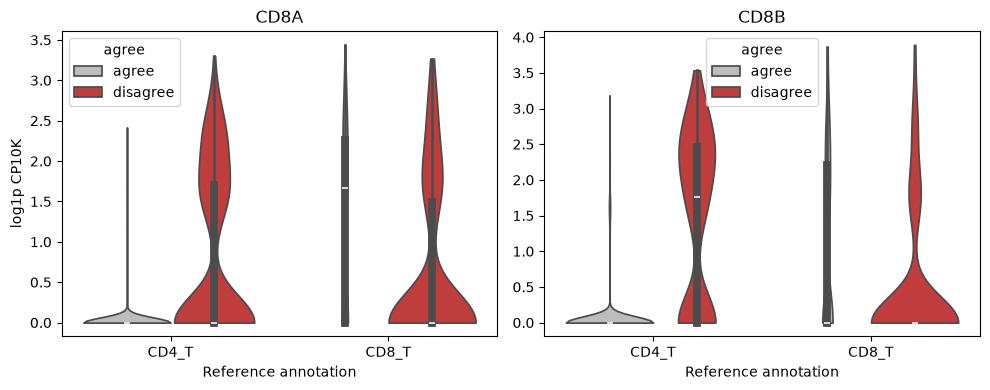

In [14]:
# Two figure

t2 = adata.obs[adata.obs["truth_coarse"].isin(["CD4_T","CD8_T"])].copy()
t2 = t2[t2["agree"] != "unassigned"]
t2["agree"] = pd.Categorical(t2["agree"].astype(str), categories=["agree","disagree"])
t2["truth_coarse"] = pd.Categorical(t2["truth_coarse"].astype(str),
                                     categories=["CD4_T","CD8_T"])

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=False)
for ax, g, col in zip(axes, ["CD8A","CD8B"], ["CD8A_expr", None]):
    v = np.asarray(ct_input[:, g].X.todense()).ravel()
    tmp = adata.obs.copy(); tmp["expr"] = v
    tmp = tmp.loc[t2.index]
    tmp["agree"] = t2["agree"]; tmp["truth_coarse"] = t2["truth_coarse"]
    sns.violinplot(data=tmp, x="truth_coarse", y="expr", hue="agree", cut=0,
                   ax=ax, palette={"agree":"#bdbdbd","disagree":"#d62728"})
    ax.set_title(g); ax.set_xlabel("Reference annotation")
    ax.set_ylabel("log1p CP10K" if g=="CD8A" else "")
plt.tight_layout()
plt.savefig(FIG / "cd8_markers_by_agreement.png", dpi=150)
plt.show()

In [15]:
# Save table

pd.concat(rows, axis=1).dropna().to_csv(ROOT / "results/marker_expr_by_agreement.csv")

In [16]:
# Now the three-way comparison:

sr = pd.read_csv(ROOT / "results/predictions_singler_hpca_fine_pbmc3k.csv")
sr = sr.set_index("barcode").loc[adata.obs_names]

with open(ROOT / "configs/ontology_map.yaml") as f:
    omap = yaml.safe_load(f)

missing = set(sr.label.unique()) - set(omap["singler_fine"])
print("unmapped:", missing or "none")

p_sr = sr.label.map(omap["singler_fine"]).values
adata.obs["singler_coarse"] = p_sr

comp = pd.DataFrame({
    "reference":  truth,
    "celltypist": p_low,
    "singler":    p_sr,
})
print(comp.apply(pd.Series.value_counts).fillna(0).astype(int))


unmapped: none
               reference  celltypist  singler
B                    342         353      363
CD4_T               1144         937     1129
CD8_T                316         429      293
DC                    37          34        0
Megakaryocyte         15          12       11
Mono_CD14            480         392      368
Mono_FCGR3A          150         229      278
NK                   154         210      159
unassigned             0          42       37


In [17]:
# Map is complete — nothing unmapped, and the two added labels shifted CD8_T to 293 and Mono_CD14 to 368.
# Now run the decisive test:

d = adata.obs.copy()
d["singler_coarse"] = p_sr
d["celltypist_coarse"] = p_low
d["cd8b"] = np.asarray(ct_input[:, "CD8B"].X.todense()).ravel()
d["cd8a"] = np.asarray(ct_input[:, "CD8A"].X.todense()).ravel()

disputed = d[(d.truth_coarse == "CD4_T") & (d.celltypist_coarse == "CD8_T")]
print("disputed cells:", len(disputed))
print()
print("what SingleR calls them:")
print(disputed.singler_coarse.value_counts())
print()
print("mean CD8A / CD8B:")
print("  disputed          :", disputed.cd8a.mean().round(3), "/", disputed.cd8b.mean().round(3))
und = d[(d.truth_coarse=="CD4_T") & (d.celltypist_coarse=="CD4_T")]
print("  undisputed CD4    :", und.cd8a.mean().round(3), "/", und.cd8b.mean().round(3))
conf = d[(d.truth_coarse=="CD8_T") & (d.celltypist_coarse=="CD8_T")]
print("  confident CD8     :", conf.cd8a.mean().round(3), "/", conf.cd8b.mean().round(3))

disputed cells: 229

what SingleR calls them:
singler_coarse
CD4_T         142
CD8_T          79
unassigned      4
B               3
NK              1
Name: count, dtype: int64

mean CD8A / CD8B:
  disputed          : 0.853 / 1.558
  undisputed CD4    : 0.036 / 0.064
  confident CD8     : 1.254 / 1.053


In [18]:
# One more check to make it airtight
# Within those 229, does SingleR's split track the markers at all or is it essentially arbitrary?

print(disputed.groupby(disputed.singler_coarse.astype(str))[["cd8a","cd8b"]].agg(["count","mean"]).round(3))

                cd8a         cd8b       
               count   mean count   mean
singler_coarse                          
B                  3  0.000     3  0.607
CD4_T            142  0.569   142  1.367
CD8_T             79  1.359    79  1.962
NK                 1  0.000     1  0.000
unassigned         4  1.802     4  1.481


In [19]:
# Dropout, to confirm means aren't driven by outliers:

for name, sub in [("disputed", disputed), ("undisputed CD4", und), ("confident CD8", conf)]:
    print(f"{name:16s} CD8B detected in {(sub.cd8b>0).mean()*100:5.1f}%  n={len(sub)}")


disputed         CD8B detected in  67.2%  n=229
undisputed CD4   CD8B detected in   3.6%  n=889
confident CD8    CD8B detected in  46.7%  n=195


In [20]:
# And the DC disappearance:

print(d[d.truth_coarse == "DC"].singler_coarse.value_counts())


singler_coarse
Mono_CD14      26
Mono_FCGR3A     6
B               3
CD8_T           1
unassigned      1
Name: count, dtype: int64


In [21]:
disputed.groupby(disputed.singler_coarse.astype(str))[["cd8a","cd8b"]].agg(
    ["count","mean"]).round(3).to_csv(ROOT / "results/disputed_cd8_analysis.csv")
disputed.groupby(disputed.singler_coarse.astype(str))[["cd8a","cd8b"]].agg(
    ["count","mean"]).round(3).to_csv(ROOT / "results/disputed_cd8_analysis.csv")

d[d.truth_coarse == "DC"].singler_coarse.value_counts().to_csv(
    ROOT / "results/dc_misassignment_singler.csv")

d[["truth_coarse","celltypist_coarse","singler_coarse","cd8a","cd8b","confidence"]].to_csv(
    ROOT / "results/three_way_comparison_pbmc3k.csv")

In [22]:
# ACTINN — the label-inheritance experiment

import glob

files = sorted(glob.glob(str(ROOT / "results/predictions_actinn_seed*_pbmc3k.csv")))
accs = []
for f in files:
    df = pd.read_csv(f)
    accs.append((df.label == df.true_label).mean())
print("ACTINN accuracy:", np.round(accs, 4))
print(f"mean {np.mean(accs):.4f}  std {np.std(accs):.4f}")

ACTINN accuracy: [0.9167 0.928  0.9192 0.8965 0.8826]
mean 0.9086  std 0.0166


In [23]:
# Now the label-inheritance test:

disputed_bc = set(disputed.index)

rows = []
for i, f in enumerate(files):
    df = pd.read_csv(f).set_index("barcode")
    hit = df.index.intersection(disputed_bc)
    if len(hit) == 0:
        continue
    rows.append(df.loc[hit].label.value_counts().rename(f"seed{i}"))

inh = pd.concat(rows, axis=1).fillna(0).astype(int)
print("ACTINN calls on the 229 disputed cells (test split only):")
print(inh)
print()
print("pooled:", inh.sum(axis=1).to_dict())
print("cells evaluated per seed:", inh.sum(axis=0).to_dict())

ACTINN calls on the 229 disputed cells (test split only):
             seed0  seed1  seed2  seed3  seed4
label                                         
CD4 T cells     62     61     66     71     73
CD8 T cells      3      1      4      1      2

pooled: {'CD4 T cells': 333, 'CD8 T cells': 11}
cells evaluated per seed: {'seed0': 65, 'seed1': 62, 'seed2': 70, 'seed3': 72, 'seed4': 75}


In [24]:
inh.to_csv(ROOT / "results/actinn_label_inheritance.csv")
pd.DataFrame({"seed": range(len(accs)), "accuracy": accs}).to_csv(
    ROOT / "results/actinn_seed_variance.csv", index=False)

In [25]:
# scANVI

# Then the comparison that matters — does scANVI show the same pattern?

import glob

sfiles = sorted(glob.glob(str(ROOT / "results/predictions_scanvi_seed*_pbmc3k.csv")))
disputed_bc = set(disputed.index)

accs_sc, rows = [], []
for i, f in enumerate(sfiles):
    df = pd.read_csv(f)
    t = df[df.split == "test"]
    accs_sc.append((t.label == t.true_label).mean())
    sub = df.set_index("barcode").loc[list(disputed_bc)]
    rows.append(sub.label.value_counts().rename(f"seed{i}"))

print("scANVI acc:", np.round(accs_sc, 4))
print(f"mean {np.mean(accs_sc):.4f}  std {np.std(accs_sc):.4f}")
print()
print("scANVI calls on the 229 disputed cells:")
inh_sc = pd.concat(rows, axis=1).fillna(0).astype(int)
print(inh_sc)
print()
print("pooled:", inh_sc.sum(axis=1).to_dict())

inh_sc.to_csv(ROOT / "results/scanvi_label_inheritance.csv")
pd.DataFrame({"seed": range(len(accs_sc)), "accuracy": accs_sc}).to_csv(
    ROOT / "results/scanvi_seed_variance.csv", index=False)


scANVI acc: [0.9293 0.9242 0.9306 0.9192 0.9331]
mean 0.9273  std 0.0050

scANVI calls on the 229 disputed cells:
                 seed0  seed1  seed2  seed3  seed4
label                                             
CD4 T cells        221    218    220    221    221
CD8 T cells          8     11      9      8      7
CD14+ Monocytes      0      0      0      0      1

pooled: {'CD4 T cells': 1101, 'CD8 T cells': 43, 'CD14+ Monocytes': 1}


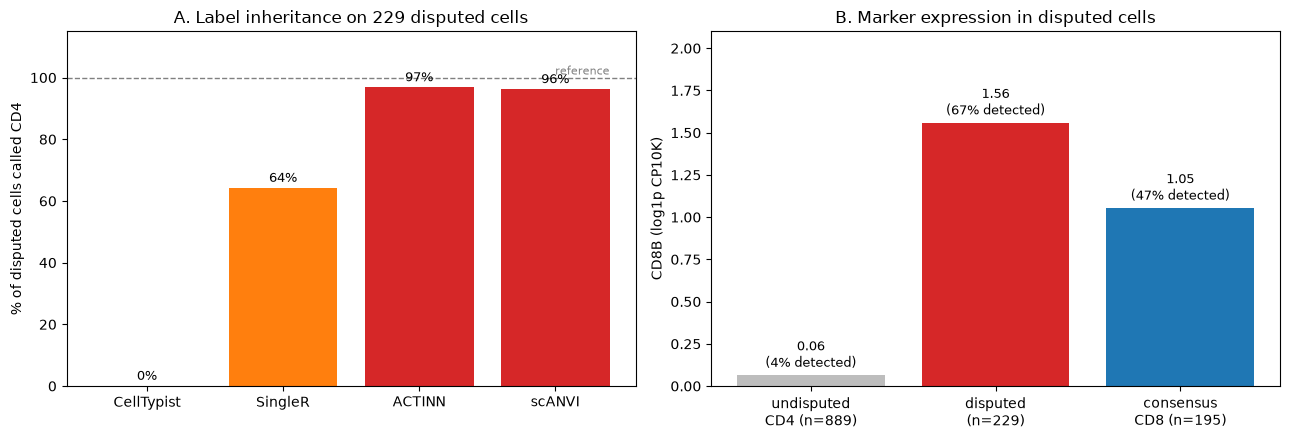

In [26]:
# First, the figure.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel A: accuracy vs label inheritance
meth = ["CellTypist", "SingleR", "ACTINN", "scANVI"]
acc  = [0.826, np.nan, np.mean(accs), np.mean(accs_sc)]
err  = [0.0, 64.2, 96.8, 96.2]

ax = axes[0]
bars = ax.bar(meth, err, color=["#2ca02c", "#ff7f0e", "#d62728", "#d62728"])
ax.set_ylabel("% of disputed cells called CD4")
ax.set_title("A. Label inheritance on 229 disputed cells")
ax.axhline(100, ls="--", lw=1, c="grey")
ax.text(3.4, 101, "reference", ha="right", fontsize=8, c="grey")
for b, v in zip(bars, err):
    ax.text(b.get_x()+b.get_width()/2, v+2, f"{v:.0f}%", ha="center", fontsize=9)
ax.set_ylim(0, 115)

# Panel B: CD8B evidence
ax = axes[1]
groups = ["undisputed\nCD4 (n=889)", "disputed\n(n=229)", "consensus\nCD8 (n=195)"]
vals   = [und.cd8b.mean(), disputed.cd8b.mean(), conf.cd8b.mean()]
det    = [(und.cd8b>0).mean()*100, (disputed.cd8b>0).mean()*100, (conf.cd8b>0).mean()*100]
ax.bar(groups, vals, color=["#bdbdbd", "#d62728", "#1f77b4"])
for i, (v, dd) in enumerate(zip(vals, det)):
    ax.text(i, v+0.05, f"{v:.2f}\n({dd:.0f}% detected)", ha="center", fontsize=9)
ax.set_ylabel("CD8B (log1p CP10K)")
ax.set_title("B. Marker expression in disputed cells")
ax.set_ylim(0, 2.1)

plt.tight_layout()
plt.savefig(FIG / "summary_label_inheritance.png", dpi=150)
plt.show()

In [27]:
disputed = d[(d.truth_coarse == "CD4_T") & (d.celltypist_coarse == "CD8_T")]

disputed

,cell_type,celltypist_coarse,truth_coarse,agree,confidence,CD8A_expr,singler_coarse,cd8b,cd8a
index,,,,,,,,,
AAACATACAACCAC-1,CD4 T cells,CD8_T,CD4_T,disagree,0.501116,1.635873,CD4_T,2.226555,1.635873
AAACTTGATCCAGA-1,CD4 T cells,CD8_T,CD4_T,disagree,0.944680,0.000000,CD4_T,0.000000,0.000000
AAATCAACCAGGAG-1,CD4 T cells,CD8_T,CD4_T,disagree,0.999810,1.519826,CD8_T,2.097141,1.519826
AAATTCGAGGAGTG-1,CD4 T cells,CD8_T,CD4_T,disagree,0.999980,0.000000,CD4_T,2.669436,0.000000
AACAATACGACGAG-1,CD4 T cells,CD8_T,CD4_T,disagree,0.999426,1.749696,CD4_T,2.996302,1.749696
...,...,...,...,...,...,...,...,...,...
TTCGAGGAGGGCAA-1,CD4 T cells,CD8_T,CD4_T,disagree,0.158418,0.000000,CD4_T,0.000000,0.000000
TTCGATTGAGCATC-1,CD4 T cells,CD8_T,CD4_T,disagree,0.464544,0.000000,CD4_T,0.000000,0.000000
TTGCTAACCACTCC-1,CD4 T cells,CD8_T,CD4_T,disagree,0.985503,0.000000,CD4_T,1.817638,0.000000


In [28]:
# Worth checking:

rev = d[(d.truth_coarse == "CD8_T") & (d.celltypist_coarse != "CD8_T")]
print(len(rev), "cells: reference CD8, CellTypist something else")
print(rev.celltypist_coarse.value_counts())
print()
print("mean CD8A / CD8B / detection:")
print("  these         :", rev.cd8a.mean().round(3), rev.cd8b.mean().round(3),
      f"{(rev.cd8b>0).mean()*100:.0f}%")
print("  consensus CD8 :", conf.cd8a.mean().round(3), conf.cd8b.mean().round(3),
      f"{(conf.cd8b>0).mean()*100:.0f}%")

121 cells: reference CD8, CellTypist something else
celltypist_coarse
NK            60
CD4_T         46
unassigned    12
B              3
Name: count, dtype: int64

mean CD8A / CD8B / detection:
  these         : 0.676 0.543 24%
  consensus CD8 : 1.254 1.053 47%


In [29]:
# quantifying 

print("disputed cells with zero CD8A AND zero CD8B:",
      ((disputed.cd8a == 0) & (disputed.cd8b == 0)).sum(), "/", len(disputed))
print()
sup = disputed[(disputed.cd8a > 0) | (disputed.cd8b > 0)]
uns = disputed[(disputed.cd8a == 0) & (disputed.cd8b == 0)]
print("mean CellTypist confidence — marker-supported:", sup.confidence.mean().round(3))
print("mean CellTypist confidence — no marker      :", uns.confidence.mean().round(3))

disputed cells with zero CD8A AND zero CD8B: 61 / 229

mean CellTypist confidence — marker-supported: 0.839
mean CellTypist confidence — no marker      : 0.611


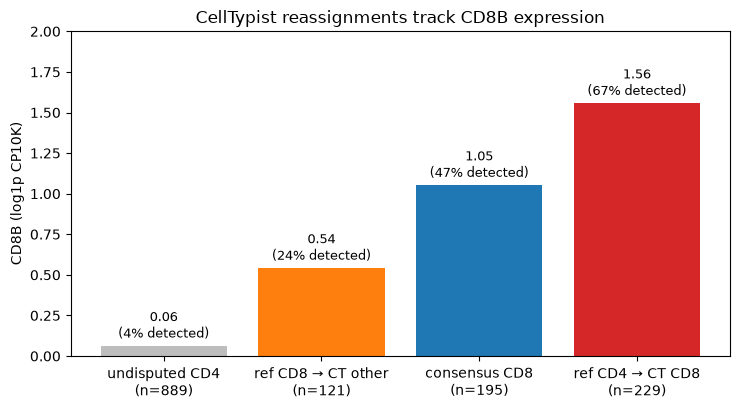

In [30]:
# Add the gradient panel 

grp = [
    ("undisputed CD4\n(n=889)",        und.cd8b,      "#bdbdbd"),
    ("ref CD8 → CT other\n(n=121)",    rev.cd8b,      "#ff7f0e"),
    ("consensus CD8\n(n=195)",         conf.cd8b,     "#1f77b4"),
    ("ref CD4 → CT CD8\n(n=229)",      disputed.cd8b, "#d62728"),
]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar([g[0] for g in grp], [g[1].mean() for g in grp], color=[g[2] for g in grp])
for i, (_, v, _) in enumerate(grp):
    ax.text(i, v.mean()+0.05, f"{v.mean():.2f}\n({(v>0).mean()*100:.0f}% detected)",
            ha="center", fontsize=9)
ax.set_ylabel("CD8B (log1p CP10K)")
ax.set_title("CellTypist reassignments track CD8B expression")
ax.set_ylim(0, 2.0)
plt.tight_layout()
plt.savefig(FIG / "cd8b_gradient_bidirectional.png", dpi=150)
plt.show()

pd.DataFrame({
    "group": ["undisputed_CD4", "ref_CD8_to_CT_other", "consensus_CD8", "ref_CD4_to_CT_CD8"],
    "n": [len(und), len(rev), len(conf), len(disputed)],
    "cd8b_mean": [g[1].mean() for g in grp],
    "cd8b_detected_pct": [(g[1]>0).mean()*100 for g in grp],
}).round(3).to_csv(ROOT / "results/cd8b_gradient.csv", index=False)

In [31]:
# Summary across all four methods
def inherit_pct(files, disputed_bc, split_col=None):
    n_cd4 = n_tot = 0
    for f in files:
        df = pd.read_csv(f).set_index("barcode")
        hit = df.index.intersection(disputed_bc)
        if len(hit) == 0:
            continue
        lab = df.loc[hit, "label"]
        n_cd4 += (lab == "CD4 T cells").sum()
        n_tot += len(lab)
    return round(100 * n_cd4 / n_tot, 1)

ct_h = ct_high["label"].map(omap["celltypist_high"]).values
ct_l = ct_low["label"].map(omap["celltypist_low"]).values
sr   = singler["label"].map(omap["singler_fine"]).values

def acc_unassigned(p):
    a = p != "unassigned"
    return round((p[a] == truth[a]).mean(), 4), round(100 * (~a).mean(), 2)

disp = pd.Series(p_low == "CD8_T", index=adata.obs_names) & pd.Series(truth == "CD4_T", index=adata.obs_names)
disputed_bc = set(adata.obs_names[disp])

acc_h, un_h = acc_unassigned(ct_h)
acc_l, un_l = acc_unassigned(ct_l)
acc_s, un_s = acc_unassigned(sr)

summary_all = pd.DataFrame([
    {"method": "CellTypist (High)",   "accuracy": acc_h, "unassigned_pct": un_h,
     "disputed_called_CD4_pct": 0.0},
    {"method": "CellTypist (Low)",    "accuracy": acc_l, "unassigned_pct": un_l,
     "disputed_called_CD4_pct": 0.0},
    {"method": "SingleR (HPCA fine)", "accuracy": acc_s, "unassigned_pct": un_s,
     "disputed_called_CD4_pct": round(100 * (sr[list(disp)] == "CD4_T").mean(), 1)},
    {"method": "ACTINN", "accuracy": round(np.mean(accs), 4), "unassigned_pct": np.nan,
     "disputed_called_CD4_pct": inherit_pct(actinn_files, disputed_bc)},
    {"method": "scANVI", "accuracy": round(np.mean(accs_sc), 4), "unassigned_pct": np.nan,
     "disputed_called_CD4_pct": inherit_pct(scanvi_files, disputed_bc)},
])

summary_all.to_csv(ROOT / "results/summary_all_methods.csv", index=False)
print(summary_all)

                method  accuracy  unassigned_pct  disputed_called_CD4_pct
0    CellTypist (High)    0.9170           78.09                      0.0
1     CellTypist (Low)    0.8263            1.59                      0.0
2  SingleR (HPCA fine)    0.8201            1.40                     62.0
3               ACTINN    0.9086             NaN                     96.8
4               scANVI    0.9273             NaN                     96.2
